In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
df_semfalha = pd.read_excel('../datasetventoinha/Experimento2/1 - Sem falhas/Coleta 1.xlsx')

df_semfalha['classificacao'] = 'sem falha'

df_semfalha.info()
df_semfalha.head()

<class 'pandas.DataFrame'>
RangeIndex: 14641 entries, 0 to 14640
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Tempo_ms       14640 non-null  object 
 1   Ax_g           14639 non-null  float64
 2   Ay_g           14639 non-null  float64
 3   Az_g           14639 non-null  float64
 4   Vibracao_g     14639 non-null  float64
 5   classificacao  14641 non-null  str    
dtypes: float64(4), object(1), str(1)
memory usage: 686.4+ KB


,Tempo_ms,Ax_g,Ay_g,Az_g,Vibracao_g,classificacao
0,0,0.0288,0.0767,0.9727,0.0239,sem falha
1,3,0.0361,0.0864,0.9604,0.0350,sem falha
2,7,0.0361,0.0850,0.9849,0.0108,sem falha
3,11,0.0337,0.0703,1.0059,0.0089,sem falha
4,15,0.0332,0.0596,0.9917,0.0060,sem falha


In [3]:
df_metadequebra = pd.read_excel('../datasetventoinha/Experimento2/2 - Pá quebrada pela metade/Coleta 1.xlsx')

df_metadequebra['classificacao'] = 'metade de quebra'

df_metadequebra.info()
df_metadequebra.head()

<class 'pandas.DataFrame'>
RangeIndex: 14224 entries, 0 to 14223
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Tempo_ms       14224 non-null  int64  
 1   Ax_g           14224 non-null  float64
 2   Ay_g           14224 non-null  float64
 3   Az_g           14224 non-null  float64
 4   Vibracao_g     14224 non-null  float64
 5   classificacao  14224 non-null  str    
dtypes: float64(4), int64(1), str(1)
memory usage: 666.9 KB


,Tempo_ms,Ax_g,Ay_g,Az_g,Vibracao_g,classificacao
0,0,0.0151,0.0635,0.9707,0.0271,metade de quebra
1,4,0.1343,-0.2051,0.6099,0.3427,metade de quebra
2,8,-0.3789,-0.3623,1.1436,0.2580,metade de quebra
3,13,-0.0957,0.6699,1.1045,0.2953,metade de quebra
4,17,0.0928,-0.0249,0.5166,0.4745,metade de quebra


In [4]:
df_totalquebra = pd.read_excel('../datasetventoinha/Experimento2/3 - Pá quebrada totalmente/Coleta 1.xlsx')

df_totalquebra['classificacao'] = 'total de quebra'

df_totalquebra.info()
df_totalquebra.head()

<class 'pandas.DataFrame'>
RangeIndex: 13855 entries, 0 to 13854
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Tempo_ms       13854 non-null  object 
 1   Ax_g           13853 non-null  float64
 2   Ay_g           13853 non-null  float64
 3   Az_g           13853 non-null  float64
 4   Vibracao_g     13853 non-null  float64
 5   classificacao  13855 non-null  str    
dtypes: float64(4), object(1), str(1)
memory usage: 649.6+ KB


,Tempo_ms,Ax_g,Ay_g,Az_g,Vibracao_g,classificacao
0,0,1.7324,1.3633,7.4863,6.8042,total de quebra
1,5,0.9141,-0.3086,7.6992,6.7594,total de quebra
2,9,-1.4102,0.3398,8.3750,7.4997,total de quebra
3,13,-0.1895,1.5801,8.3398,7.4903,total de quebra
4,17,1.9883,0.8047,7.4414,6.7444,total de quebra


In [5]:
df_umquartoquebra = pd.read_excel('../datasetventoinha/Experimento2/4 - Pá quebrada por um quarto/Coleta 1.xlsx')

df_umquartoquebra['classificacao'] = 'um quarto de quebra'

df_umquartoquebra.info()
df_umquartoquebra.head()

<class 'pandas.DataFrame'>
RangeIndex: 13941 entries, 0 to 13940
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Tempo_ms       13940 non-null  object 
 1   Ax_g           13939 non-null  float64
 2   Ay_g           13939 non-null  float64
 3   Az_g           13939 non-null  float64
 4   Vibracao_g     13939 non-null  float64
 5   classificacao  13941 non-null  str    
dtypes: float64(4), object(1), str(1)
memory usage: 653.6+ KB


,Tempo_ms,Ax_g,Ay_g,Az_g,Vibracao_g,classificacao
0,0,-0.1777,0.6875,7.9219,6.9536,um quarto de quebra
1,5,0.8047,0.9004,7.6699,6.7644,um quarto de quebra
2,9,0.6621,0.0996,7.6230,6.6524,um quarto de quebra
3,13,-0.3984,-0.1621,7.7207,6.7327,um quarto de quebra
4,17,-0.1641,0.8281,8.0937,7.1377,um quarto de quebra


In [6]:
df_umoitavoquebra = pd.read_excel('../datasetventoinha/Experimento2/7 - Pá com um oitavo de quebra/Coleta 1.xlsx')

df_umoitavoquebra['classificacao'] = 'um oitavo de quebra'

df_umoitavoquebra.info()
df_umoitavoquebra.head()

<class 'pandas.DataFrame'>
RangeIndex: 14749 entries, 0 to 14748
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Tempo_ms       14748 non-null  object 
 1   Ax_g           14747 non-null  float64
 2   Ay_g           14747 non-null  float64
 3   Az_g           14747 non-null  float64
 4   Vibracao_g     14747 non-null  float64
 5   classificacao  14749 non-null  str    
dtypes: float64(4), object(1), str(1)
memory usage: 691.5+ KB


,Tempo_ms,Ax_g,Ay_g,Az_g,Vibracao_g,classificacao
0,0,-7.5254,-3.9785,-11.9946,13.7082,um oitavo de quebra
1,4,0.0415,0.0894,0.9795,0.0156,um oitavo de quebra
2,8,0.0327,0.0337,0.9697,0.0291,um oitavo de quebra
3,12,0.0000,0.0366,1.0176,0.0182,um oitavo de quebra
4,15,-0.0068,0.0806,1.0029,0.0062,um oitavo de quebra


In [7]:
df_microquebra = pd.read_excel('../datasetventoinha/Experimento2/5 - Pá com micro quebra/Coleta 1.xlsx')

df_microquebra['classificacao'] = 'micro quebra'

df_microquebra.info()
df_microquebra.head()

<class 'pandas.DataFrame'>
RangeIndex: 13766 entries, 0 to 13765
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Tempo_ms       13765 non-null  object 
 1   Ax_g           13764 non-null  float64
 2   Ay_g           13764 non-null  float64
 3   Az_g           13764 non-null  float64
 4   Vibracao_g     13764 non-null  float64
 5   classificacao  13766 non-null  str    
dtypes: float64(4), object(1), str(1)
memory usage: 645.4+ KB


,Tempo_ms,Ax_g,Ay_g,Az_g,Vibracao_g,classificacao
0,0,-0.3789,-1.0898,8.0918,7.1736,micro quebra
1,5,-2.3164,2.0332,8.3164,7.8692,micro quebra
2,9,3.4297,-0.0859,7.7910,7.5129,micro quebra
3,13,-2.2832,-0.5449,7.5391,6.8960,micro quebra
4,17,0.0547,1.6191,9.2051,8.3466,micro quebra


In [8]:
df_desbalanceada = pd.read_excel('../datasetventoinha/Experimento2/6 - Pá desbalanceada/Coleta 1.xlsx')

df_desbalanceada['classificacao'] = 'pa desbalanceada'

df_desbalanceada.info()
df_desbalanceada.head()

<class 'pandas.DataFrame'>
RangeIndex: 14551 entries, 0 to 14550
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Tempo_ms       14550 non-null  object 
 1   Ax_g           14549 non-null  float64
 2   Ay_g           14549 non-null  float64
 3   Az_g           14549 non-null  float64
 4   Vibracao_g     14549 non-null  float64
 5   classificacao  14551 non-null  str    
dtypes: float64(4), object(1), str(1)
memory usage: 682.2+ KB


,Tempo_ms,Ax_g,Ay_g,Az_g,Vibracao_g,classificacao
0,0,0.0249,0.1689,1.0059,0.0203,pa desbalanceada
1,4,0.0981,0.1157,1.0195,0.0308,pa desbalanceada
2,8,0.0029,0.0117,0.9941,0.0058,pa desbalanceada
3,12,-0.0723,0.0542,1.0210,0.0250,pa desbalanceada
4,16,-0.0073,0.1641,0.9893,0.0028,pa desbalanceada


In [13]:
tamanho_janela_ms = 333

# 1. Garante que Tempo_ms seja numérico (converte erros/textos inválidos para NaN)
df_unificado['Tempo_ms'] = pd.to_numeric(
    df_unificado['Tempo_ms'], errors='coerce'
)

# 2. Remove eventuais linhas onde Tempo_ms era texto inválido/nulo
df_unificado = df_unificado.dropna(subset=['Tempo_ms'])

# 3. Cria a coluna ID_Janela
df_unificado['ID_Janela'] = (
    df_unificado['Tempo_ms'] // tamanho_janela_ms
).astype(int)

# 4. Agrupamento/Features
df_features = (
    df_unificado.groupby(['classificacao', 'ID_Janela'])
    .agg(
        Ax_Mean=('Ax_g', 'mean'),
        Ax_Std=('Ax_g', 'std'),
        Ax_Max=('Ax_g', 'max'),
        Ax_Min=('Ax_g', 'min'),
        Ay_Mean=('Ay_g', 'mean'),
        Ay_Std=('Ay_g', 'std'),
        Ay_Max=('Ay_g', 'max'),
        Ay_Min=('Ay_g', 'min'),
        Az_Mean=('Az_g', 'mean'),
        Az_Std=('Az_g', 'std'),
        Az_Max=('Az_g', 'max'),
        Az_Min=('Az_g', 'min'),
    )
    .reset_index()
)

df_features = df_features.dropna().reset_index(drop=True)

print("Dimensão do dataset final:", df_features.shape)
df_features.head()

Dimensão do dataset final: (1267, 14)


,classificacao,ID_Janela,Ax_Mean,Ax_Std,Ax_Max,Ax_Min,Ay_Mean,Ay_Std,Ay_Max,Ay_Min,Az_Mean,Az_Std,Az_Max,Az_Min
0,metade de quebra,0,0.203907,0.362668,0.8838,-0.3789,0.113157,0.490089,0.8135,-0.4814,0.989730,0.333036,1.4375,0.5166
1,metade de quebra,1,0.165069,0.350335,0.8960,-0.2314,0.128620,0.520733,0.8306,-0.4912,0.955430,0.341918,1.4375,0.5171
2,metade de quebra,2,-0.056752,0.264587,0.7603,-0.5264,0.089872,0.474978,0.8384,-0.4814,0.930390,0.279641,1.4380,0.5132
3,metade de quebra,3,-0.011838,0.345135,0.9004,-0.5186,0.054744,0.409094,0.8311,-0.4819,0.968264,0.243633,1.4473,0.5190
4,metade de quebra,4,0.052718,0.356614,0.9048,-0.5103,0.079795,0.437963,0.8389,-0.4849,0.973222,0.273726,1.4561,0.5117


Acurácia Total: 100.00%

Relatório de Classificação:

                     precision    recall  f1-score   support

   metade de quebra       1.00      1.00      1.00        36
       micro quebra       1.00      1.00      1.00        36
   pa desbalanceada       1.00      1.00      1.00        36
          sem falha       1.00      1.00      1.00        37
    total de quebra       1.00      1.00      1.00        36
um oitavo de quebra       1.00      1.00      1.00        36
um quarto de quebra       1.00      1.00      1.00        37

           accuracy                           1.00       254
          macro avg       1.00      1.00      1.00       254
       weighted avg       1.00      1.00      1.00       254



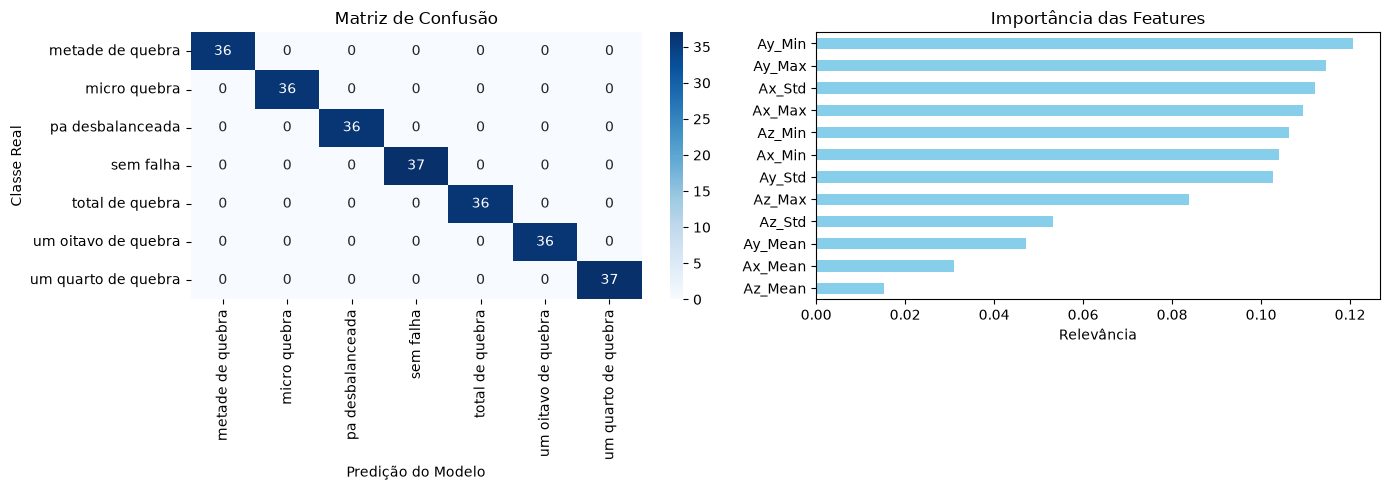

In [15]:
X = df_features.drop(columns=['classificacao', 'ID_Janela'])
y = df_features['classificacao']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(n_estimators=100, random_state=67)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Acurácia Total: {acc * 100:.2f}%\n")
print("Relatório de Classificação:\n")
print(classification_report(y_test, y_pred))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
m = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)
sns.heatmap(m, annot=True, fmt='d', cmap='Blues', 
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_, ax=axes[0])
axes[0].set_title('Matriz de Confusão')
axes[0].set_xlabel('Predição do Modelo')
axes[0].set_ylabel('Classe Real')

# Importância das Features
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot(kind='barh', ax=axes[1], color='skyblue')
axes[1].set_title('Importância das Features')
axes[1].set_xlabel('Relevância')

plt.tight_layout()
plt.show()